In [397]:
import handcalcs.render
import numpy as np
from scipy.constants import speed_of_light, Boltzmann, pi
import matplotlib.pyplot as plt
from math import pi, sqrt, exp
import forallpeople as si
from scipy.integrate import quad
import sympy as sp


In [398]:
si.environment('default', top_level=True)
handcalcs.set_option('use_scientific_notation', True)
handcalcs.set_option('display_precision', 6)
handcalcs.set_option("custom_symbols", {"v_bar": "\\bar{v}", "N_trap_dot": "\\dot{N}"})
sp.init_printing()

In [399]:
gam, I, I_sat, det= sp.symbols('gam I I_sat det', real=True, positive=True)

In [400]:
%%render params
delta = 50e9 /s #detuning in Hz
laser_wav = 852e-09*m # laser wavelegnth
wav = 780e-09*m # transition wavelength
M_Rb = 1.443*1e-25 *kg # kg mass of Rb 87
hbar = 1.054571817e-34 * (kg * m**2 / s)
k_B = 1.380649e-23 * si.kg * si.m**2 / (si.s**2 * si.K)
Gamma  = 2*pi * 6.065 *1e6 *Hz #transition frequency Gamma
w_0 = 780 * 1e-9 *m#transition wavelength
laser_power = 1e-06  *W#Watt
laser_waist = 10e-6 *m #laser waist
c = 300000000 *m/s
I_satur = 16.7 *W/m**2 #saturation intensity
F= 300 #Finesse of the cavity


<IPython.core.display.Latex object>

In [401]:
detune = detuning = 2*pi*c*(1/wav - 1/laser_wav) #wont allow proper units

In [402]:
def R_scatt(gam, I, I_sat, det):
    num = gam / 2 * I / I_sat
    denom = 1 + I/I_sat +(2*det/gam)**2
    return num/denom
# def R_scatt(gam, I, I_sat, det):
#     num = gam**3 * I
#     denom = 8*det**2 *I_sat
#     return num/denom

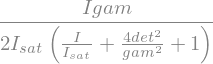

In [403]:
R_scatt(gam, I, I_sat, det)

In [404]:
Rate = R_scatt(gam, I, I_sat, det)

In [405]:

cavity_power = F/sp.pi * laser_power.value
intensity = 2*cavity_power/(sp.pi*laser_waist.value**2)*W/m**2

In [406]:
%%render sympy
gam = Gamma
I= intensity
I_sat = I_satur
det = delta #detune

<IPython.core.display.Latex object>

In [407]:
%%render sympy
R_scat = Rate


<IPython.core.display.Latex object>